## Applied Machine Learning, Module 1:  A simple classification task

In [113]:
%matplotlib notebook
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [114]:
PARENT_DIR = "Lab Files\\resources\\course3\\"

In [115]:
fruits = pd.read_table(PARENT_DIR + "assets\\fruit_data_with_colors.txt")
fruits.head()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79


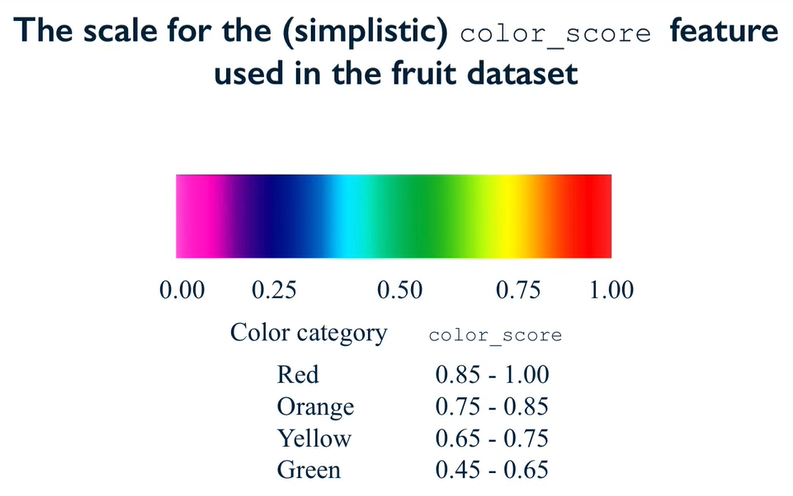

In [116]:
# look up fruit name
lookup_fruit_name = dict(zip(fruits['fruit_label'].unique(), fruits['fruit_name'].unique()))
lookup_fruit_name

{np.int64(1): 'apple',
 np.int64(2): 'mandarin',
 np.int64(3): 'orange',
 np.int64(4): 'lemon'}

### Create train-test split

In [117]:
# independent variables: mass, width, height
# dependent variable: fruit_label
X = fruits[['mass', 'width', 'height', 'color_score']]
y = fruits['fruit_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0) #random_state is usually set to 42

In [118]:
def find_outliers_by_iqr(arr):
    q1, q3 = np.percentile(arr, [25, 75])
    iqr = q3 - q1
    lower_bound, upper_bound = q1 - 1.5*iqr, q3 + 1.5*iqr
    return [data for data in arr if data < lower_bound or data > upper_bound]

print(find_outliers_by_iqr(fruits['width']))
print(find_outliers_by_iqr(fruits['mass']))
print(find_outliers_by_iqr(fruits['height']))

[9.0, 9.2, 9.6]
[84, 80, 80, 76, 342, 356, 362]
[4.7, 4.6, 4.3, 4.3, 4.0, 10.3, 10.5, 10.2, 9.7, 10.1]


### Plot feature pair plot
Shows relation between features

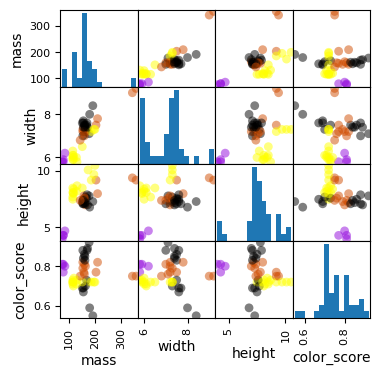

In [119]:
cmap = plt.get_cmap('gnuplot')
scatter = pd.plotting.scatter_matrix(
    X_train,
    c = y_train,
    marker='o',
    s = 40,
    hist_kwds={'bins': 15},
    figsize=(4,4),
    cmap = cmap
)

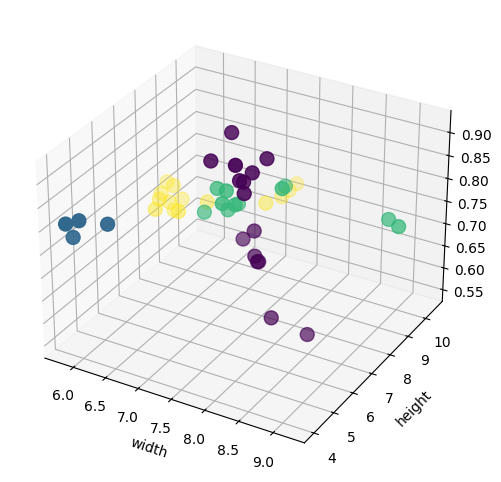

In [120]:
# plotting a 3D scatter plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(X_train['width'], X_train['height'], X_train['color_score'], c = y_train, marker = 'o', s=100)
ax.set_xlabel('width')
ax.set_ylabel('height')
# ax.set_zlabel('color_score')
plt.show()

C:\Users\shurai\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


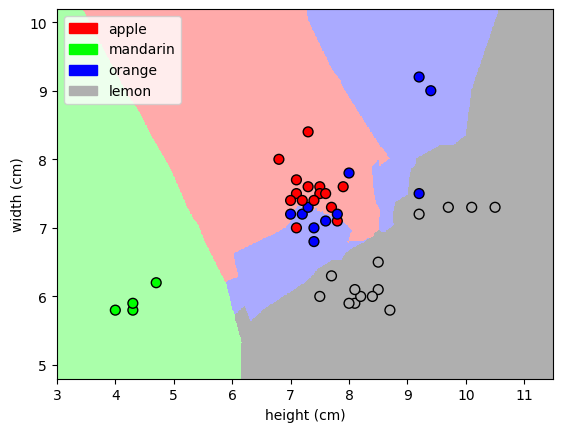

In [121]:
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn import neighbors

def plot_fruit_knn(X, y, n_neighbors, weights):
    X_mat = X[['height', 'width']].values
    y_mat = y.values

    # Create color maps
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF','#AFAFAF'])
    cmap_bold  = ListedColormap(['#FF0000', '#00FF00', '#0000FF','#AFAFAF'])

    clf = neighbors.KNeighborsClassifier(n_neighbors, weights=weights)
    clf.fit(X_mat, y_mat)

    # Plot the decision boundary by assigning a color in the color map
    # to each mesh point.
    
    mesh_step_size = .01  # step size in the mesh
    plot_symbol_size = 50
    
    x_min, x_max = X_mat[:, 0].min() - 1, X_mat[:, 0].max() + 1
    y_min, y_max = X_mat[:, 1].min() - 1, X_mat[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, mesh_step_size),
                         np.arange(y_min, y_max, mesh_step_size))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.figure()
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    # Plot training points
    plt.scatter(X_mat[:, 0], X_mat[:, 1], s=plot_symbol_size, c=y, cmap=cmap_bold, edgecolor = 'black')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

    patch0 = mpatches.Patch(color='#FF0000', label='apple')
    patch1 = mpatches.Patch(color='#00FF00', label='mandarin')
    patch2 = mpatches.Patch(color='#0000FF', label='orange')
    patch3 = mpatches.Patch(color='#AFAFAF', label='lemon')
    plt.legend(handles=[patch0, patch1, patch2, patch3])

        
    plt.xlabel('height (cm)')
    plt.ylabel('width (cm)')
    
    plt.show()

plot_fruit_knn(X_train, y_train, 5, 'uniform')


#### Prediction part

In [122]:
fruits.columns

Index(['fruit_label', 'fruit_name', 'fruit_subtype', 'mass', 'width', 'height',
       'color_score'],
      dtype='object')

In [123]:
# create train, test, split
X = fruits[['mass', 'width', 'height']]
y = fruits['fruit_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [124]:
# create classifier object
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

In [125]:
# Train the classifier (fit the estimator) using the training data
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [126]:
# Estimate the accuracy of the classifier on future data, using the test data
knn.score(X_test, y_test)

0.5333333333333333

In [127]:
# Use the trained k-NN classifier model to classify new, previously unseen objects
# first example: a small fruit with mass 20g, width 4.3 cm, height 5.5 cm

new_data = pd.DataFrame([[20, 4.3, 5.5]], columns=X_train.columns)

fruit_prediction = knn.predict(new_data)
lookup_fruit_name.get(fruit_prediction[0])

'mandarin'

In [131]:
# second example: a larger, elongated fruit with mass 100g, width 6.3 cm, height 8.5 cm
new_data = pd.DataFrame([[100, 6.3, 8.5]], columns=X_train.columns)
fruit_prediction = knn.predict(new_data)
lookup_fruit_name.get(fruit_prediction[0])

'lemon'

#### How sensitive is k-NN classification accuracy to the choice of the 'k' parameter?

([<matplotlib.axis.XTick at 0x1a8237d50d0>,
 [Text(0, 0, '0'),
  Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20')])

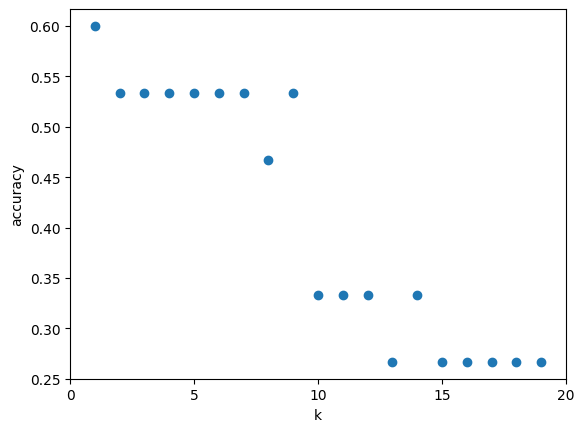

In [132]:
k_range = range(1,20)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

plt.figure()
plt.xlabel('k')
plt.ylabel('accuracy')
plt.scatter(k_range, scores)
plt.xticks([0,5,10,15,20])

In [141]:
# trying prdictions with first example for different k values
# first example: a small fruit with mass 20g, width 4.3 cm, height 5.5 cm

data = pd.DataFrame([[20, 4.3, 5.5]], columns=X_train.columns)
res_dict = {}
for k in range(1, 10):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    res_dict[k] = lookup_fruit_name.get(knn.predict(new_data)[0])

res_dict


{1: 'mandarin',
 2: 'mandarin',
 3: 'lemon',
 4: 'lemon',
 5: 'lemon',
 6: 'lemon',
 7: 'lemon',
 8: 'lemon',
 9: 'lemon'}

In [143]:
# with k = sqrt(n)
knn = KNeighborsClassifier(n_neighbors=int((len(X_train)**0.5)))
knn.fit(X_train, y_train)
lookup_fruit_name.get(knn.predict(new_data)[0])

'lemon'

In [145]:
fruits.shape

(59, 7)